Testing out the pattern template matching method for finding replay events
- use the tuning curves as the template
- try to find the homings first
- try to find any other events
- rank order in candidate events can be defined as first time active (above zscore threshold), weighted avg activity, rastermap sorting

Method from Diba and Buzsaki 2007
- define the place fields of the cells
- template is made by using peak firing location
- in times of interest look over a sliding window of 300ms for times when 30% of cells in template fired
- create sequence using the first spiketime of each cell in the 300ms window
- rank order correlation between candidate event and sequence template
- significance testing

In [ ]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.process.process import Process
from JR_test_scripts.escape.functions.escape_utils import load_homing, load_hdir_cells, load_significant_cells
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar

import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
from loguru import logger
import dill as pickle
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy.stats import zscore
from rastermap import Rastermap
from syd import make_viewer
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded in PDF

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
"""Load the data"""
c_names = ['shelter_only', 'barrier', 'flipped_barrier']
conditions = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
explore_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves_explore/")
homie_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
save_path = make_directory("Z:/Jasmine_Laurence/summary_plots/Replay/PreHomingSorted")
tuning_data = '_25bins' # '' or '_50bins' or '_25bins
cond_colors = ['#228B22','#FF8C00','#008B8B']
homing_color = '#6A0DAD'
escape_color = '#E63946'
exp = JAL6_flip4_21mar
session_name = "JAL6_flip4_21mar"
cond = 1

In [8]:
"""Load tuning data.
We need to identify significant cells and their tuning preference - build the template"""
sig_cells = load_significant_cells(exp, case = "either_tuned", tuning_data = tuning_data)
hdir = load_hdir_cells([exp], [session_name])
sig_cells[hdir,:] = np.full(3, False)

exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + 'escape'
data = np.load(homie_path + exp_nickname + '_ProperTuning' + tuning_data + '.npz')
sig_escape = data['params_real'][:,:,0] > np.nanpercentile(data['params_shifts'][:,:,:,0], 95, axis = 0)
preferred_tuning = data['params_full'][:,:,1]
template_seq = np.argsort(preferred_tuning[sig_cells[:,cond],cond])

2025-04-30 16:42:23.446 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [5]:
"""Load frame by cluster matrix
This should probably be zscored!"""
session = Process(exp).load_session()
base_path = os.path.join(session.base_path, session.processed_path)

# matrix
fcm = np.load(
    os.path.join(session.base_path, session.processed_path)
    + "\\"
    + "frame_by_good_cluster_matrix.npy"
)

# only keep sig cells in this condition
fcm = gaussian_filter1d(fcm[:,sig_cells[:,cond]], 2, axis = 0)

# only keep timepoints in this condition
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))
bar = video_df["barrier_present"].to_numpy()
barflip = video_df["barrier_flipped"].to_numpy()
condition = np.zeros(len(bar))
condition[bar] += 1
condition[barflip] += 1

# select condtion and sort by pref tuning
fcm = fcm[condition == cond,:]
fcm = fcm[:,template_seq]

# zscore neural data
fcm = zscore(fcm, axis = 0) # time x neurons

2025-04-30 16:23:58.548 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


In [11]:
"""Load the homing data"""
h_on, h_off, homing_bool = load_homing(session, int(np.amax(np.unique(video_df['frames'].to_numpy()))))

# booleans for homing+escape and explore
# TODO this is a hack into the escapes to remove the 1s of pause before they start running
escape = video_df['EscapePeriod'].to_numpy()
escape_bool = np.full_like(escape, False)
start = np.where(np.diff(escape.astype(int)) == 1)[0]
end = np.where(np.diff(escape.astype(int)) == -1)[0]
for s, e in zip(start, end):
    escape_bool[s+40:e] = True

h_e_bool = (homing_bool | escape_bool) & (video_df['OutofshelterIdx'].to_numpy())
h_e_bool = h_e_bool[condition == cond]

2025-04-30 16:43:27.716 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [22]:
"""Sliding window search
Over windows of 300ms, search for periods when 30% of cells are active (> 1 zscore?)"""
window_ms = 5000
window_samples = int((window_ms/1000)*40)
step = int(1*40) # step every 100ms
threshold = 4 # zscore threshold
frac_active = .3

identified_window = []
identified_num_active = []
activity = np.full(fcm.shape[0], False)

for i in range(0, fcm.shape[0]-window_samples, step):
    window = fcm[i:i+window_samples,:] > threshold
    time_over_t = np.sum(window, axis = 0) # number of timepoints above threshold
    num_active = np.sum(time_over_t > 0) # number of active cells
    # check if 30% of cells are active
    if num_active > (frac_active * window.shape[1]):
        activity[i:i+window_samples] = True
        identified_window.append(i)
        identified_num_active.append(num_active)

# there will be some consecutive windows with overlapping activity
# find consecutive windows, look at which one has the highest fraction of active cells
# only keep the one with the most active cells
# Step 1: Find breaks between consecutive windows
diff_window_time = np.diff(identified_window)
breaks = np.where(diff_window_time > 40)[0]
breaks = np.append(breaks, len(identified_window)-1)  # Add the last index

# Step 2: Process each group of consecutive windows
start_idx = 0
best_windows = []
best_activity = np.full(fcm.shape[0], False)  # Initialize best activity array

for end_idx in breaks:
    # Extract the current group of consecutive windows
    group = identified_window[start_idx:end_idx+1]
    
    if len(group) == 0:
        continue
        
    # Find the window with highest fraction of active cells in this group
    group_fractions = [identified_num_active[a] for win_idx in group for a,x, in enumerate(identified_window) if x == win_idx]
    best_window_idx = start_idx + np.argmax(group_fractions)
    
    # Keep only the best window from this group
    best_windows.append(identified_window[best_window_idx])

    # Update the best activity array
    best_activity[identified_window[best_window_idx]:identified_window[best_window_idx] + window_samples] = True
    
    # Move to the next group
    start_idx = end_idx + 1

# Convert to array for easier handling
best_windows = np.array(best_windows)

(-0.5, 3.0)

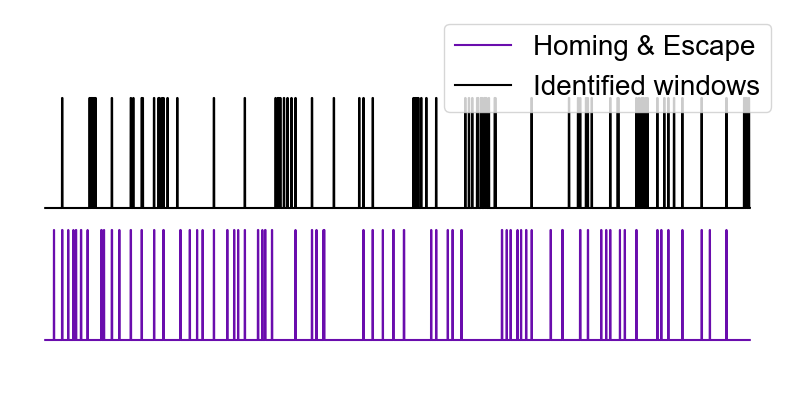

In [14]:
"""Look at the overlap between homing periods and the best windows"""
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
axs.plot(h_e_bool, color = homing_color, label = 'Homing & Escape')
axs.plot(best_activity+1.2, color = 'k', label = 'Identified windows')
axs.set_axis_off()
axs.legend(loc = 'upper right', fontsize = 20)
axs.set_ylim([-0.5, 3])

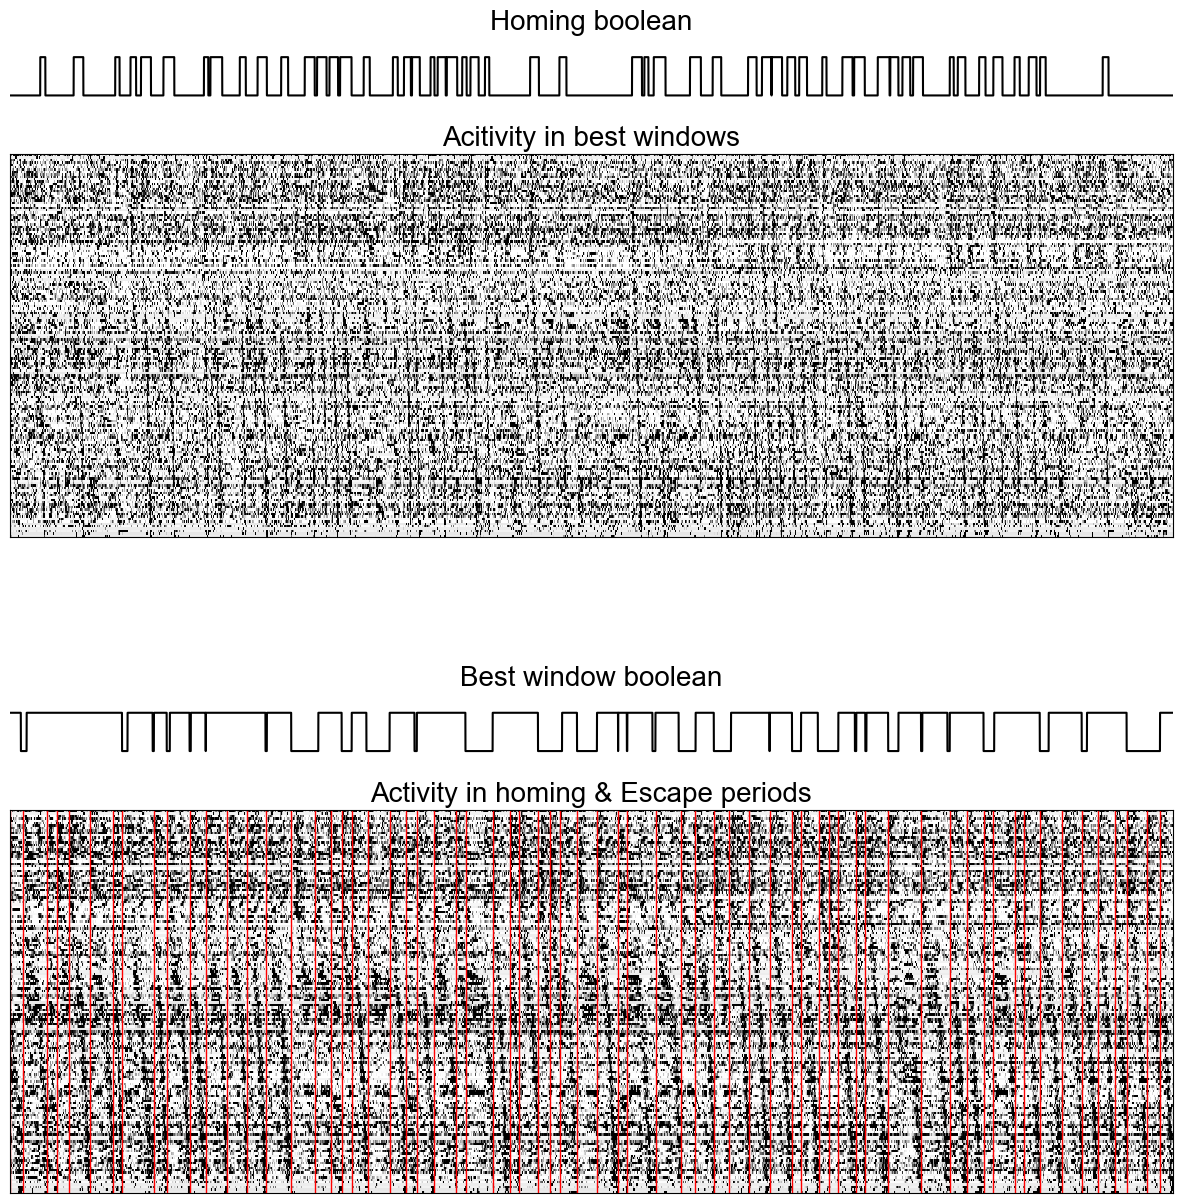

In [23]:
"""Look at the best windows and whether they are in the homing or escape period"""
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(5, 1, height_ratios=[1, 5, 1, 1, 5])

ax0 = fig.add_subplot(gs[0])
ax0.plot(h_e_bool[best_activity], color = 'black')
ax0.set_ylim(-.5, 1.5)
ax0.set_xlim(0, np.sum(best_activity))
ax0.set_xticks([])
ax0.set_axis_off()
ax0.set_title('Homing boolean', fontsize = 20)

ax1 = fig.add_subplot(gs[1])
ax1.imshow(fcm[best_activity,:].T, vmin = -.5, vmax = 1.5, aspect = 'auto', cmap = 'Greys', interpolation= "none")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Acitivity in best windows', fontsize = 20)
# add vertical lines to indicate the start and end of homing periods
# for e in np.arange(0, np.sum(best_activity), window_samples):
    # ax1.axvline(x = e, color = 'red', linestyle = '-', linewidth = 1)

ax0 = fig.add_subplot(gs[3])
ax0.plot(best_activity[h_e_bool], color = 'black')
ax0.set_ylim(-.5, 1.5)
ax0.set_xlim(0, np.sum(h_e_bool))
ax0.set_xticks([])
ax0.set_axis_off()
ax0.set_title('Best window boolean', fontsize = 20)

ax1 = fig.add_subplot(gs[4])
ax1.imshow(fcm[h_e_bool,:].T, vmin = -.5, vmax = 1.5, aspect = 'auto', cmap = 'Greys', interpolation= "none")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Activity in homing & Escape periods', fontsize = 20)

# add vertical lines to indicate the start and end of homing periods
h_start = np.where(np.diff(h_e_bool.astype(int)) == 1)[0]
h_end = np.where(np.diff(h_e_bool.astype(int)) == -1)[0]
counter = 0
for s,e in zip(h_start, h_end):
    ax1.axvline(x = counter, color = 'red', linestyle = '-', linewidth = 1)
    counter += e-s

In [35]:
def run_rastermap(escape_matrix):
  # rastermap with running speed and y position

    fit_spks = zscore(escape_matrix.T, axis=1) # need neurons x time
    if np.shape(fit_spks)[0] > 200:
        model = Rastermap(n_clusters=100, # number of clusters to compute
                            n_PCs=128, # number of PCs to use
                            locality=0., # locality in sorting to find sequences (this is a value from 0-1)
                            grid_upsample=10, # default value, 10 is good for large recordings
                            ).fit(fit_spks)
    else:
        model = Rastermap(n_clusters=None, # None turns off clustering and sorts single neurons 
                        n_PCs=64, # use fewer PCs than neurons
                        locality=0.15, # some locality in sorting (this is a value from 0-1)
                        time_lag_window=40, # use future timepoints to compute correlation
                        grid_upsample=0, # 0 turns off upsampling since we're using single neurons
                        ).fit(fit_spks)
    isort = model.isort
    return isort, fit_spks

def generate_event_seq(n_window, threshold, window_samples, method = 'first_activity'):
    """INPUTS:
    n_window: 2D array of neural activity (time x neurons)
    threshold: zscore threshold for activity
    window_samples: number of samples in the window (e.g. 500ms = 200 samples at 40Hz)
    method: method for generating event sequence (default is 'first_activity')
    """
    # event_seq based on first activity as moment when it crosses threshold
    if method == 'first_activity':
        first_activity = np.zeros(n_window.shape[1])
        for n in range(n_window.shape[1]):
            if len(np.where((n_window[:,n] > threshold) == True)[0]) > 0:
                first_activity[n] = np.where((n_window[:,n] > threshold) == True)[0][0]
        event_seq = np.argsort(first_activity)

    # event seq based on weighted average of activity to find where the bump is
    if method == 'weighted_avg':
        weighted_avg = np.zeros(n_window.shape[1])
        for n in range(n_window.shape[1]):
            weighted_avg[n] = np.sum(n_window[:,n] * np.arange(1, window_samples+1)) / np.sum(n_window[:,n])
        event_seq = np.argsort(weighted_avg)

    # event seq based on rastermap sorting
    if method == 'rastermap':
        event_seq, _ = run_rastermap(n_window)

    return event_seq

In [37]:
"""Let's syd it"""

def plot(state):

    win = best_windows[state['window idx']]
    n_window = fcm[win:win+window_samples,:]

    fig, axs = plt.subplots(2, 3, figsize=(20, 10), height_ratios = [.5,5])

    axs[0,0].plot(h_e_bool[win:win+window_samples], color = homing_color)
    axs[0,0].set_ylim(-.5, 1.5)
    axs[0,0].set_yticks([0,1])
    axs[0,0].set_xticks([])
    axs[0,0].set_xlim(0, window_samples)
    axs[0,0].spines['right'].set_visible(False)
    axs[0,0].spines['top'].set_visible(False)
    axs[0,0].spines['bottom'].set_visible(False)

    axs[1,0].imshow(n_window.T, vmin = -.5, vmax = 1.5, aspect = 'auto', cmap = 'Greys', interpolation= "none")
    axs[0,0].set_title('Best window \n' + r'sorted on %escape tuning', fontsize = 30)

    event_seq = generate_event_seq(n_window, state['zscore_thresh'], window_samples, method = state['method'])

    axs[1,1].imshow(n_window[:,event_seq].T, vmin = -.5, vmax = 1.5, aspect = 'auto', cmap = 'Greys', interpolation= "none")
    axs[0,1].set_title('Best window \n sorted on activity in event', fontsize = 30)
    axs[0,1].set_axis_off()

    axs[1,2].scatter(np.arange(n_window.shape[1]), event_seq)
    correlation, p_value = spearmanr(np.arange(n_window.shape[1]), event_seq)

    axs[0,2].set_title(f"Rank correlation: {correlation:.3f}" + '\n' + f"p-value: {p_value:.5f}", fontsize = 30)
    axs[0,2].set_axis_off()
    axs[1,2].set_xlabel("Template order")
    axs[1,2].set_ylabel("Activation Order")
    axs[1,2].set_box_aspect(1)
    axs[1,2].set_xticks([])
    axs[1,2].set_yticks([])

    plt.tight_layout()
    return fig

In [ ]:
viewer = make_viewer()
viewer.add_integer('window idx', min = 0, max = len(best_windows)-1)
viewer.add_integer('zscore_thresh', min = 1, max = 5)
viewer.add_selection(name = 'method', options = ['first_activity', 'weighted_avg', 'rastermap'])

viewer.set_plot(plot)
viewer.show()

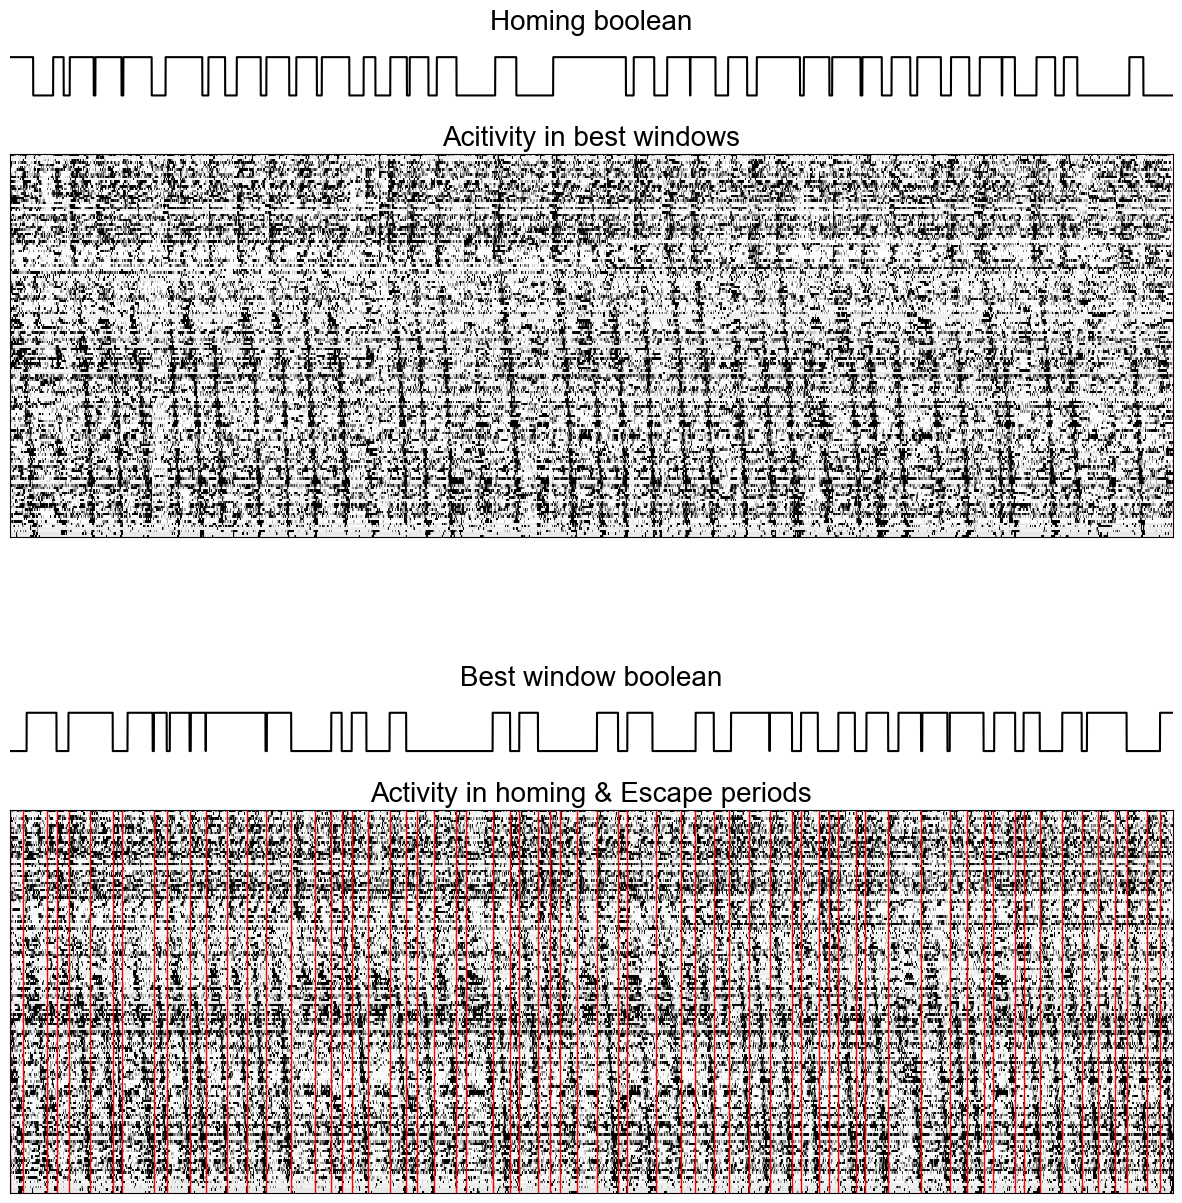

In [198]:
"""Check the correlation between the ranking of the best windows and the homing periods"""
corr_threshold = 0.2
corr_pass = np.full(fcm.shape[0], False)

for win in best_windows:
    # threshold the activity in the window
    n_window = fcm[win:win+window_samples,:]

    # find the first time where each cell was active
    first_activity = np.zeros(n_window.shape[1])
    for n in range(n_window.shape[1]):
        if len(np.where((n_window[:,n] > threshold) == True)[0]) > 0:
            first_activity[n] = np.where((n_window[:,n] > threshold) == True)[0][0]
    event_seq = np.argsort(first_activity)
    
    # rank order correlation
    correlation, p_value = spearmanr(np.arange(n_window.shape[1]), event_seq)
    if np.abs(correlation) > corr_threshold:
        corr_pass[win:win+window_samples] = True


"""Look at the windows that passed correlation test and whether they are in the homing or escape period"""
fig = plt.figure(figsize=(15, 15))
gs = gridspec.GridSpec(5, 1, height_ratios=[1, 5, 1, 1, 5])

ax0 = fig.add_subplot(gs[0])
ax0.plot(h_e_bool[corr_pass], color = 'black')
ax0.set_ylim(-.5, 1.5)
ax0.set_xlim(0, np.sum(corr_pass))
ax0.set_xticks([])
ax0.set_axis_off()
ax0.set_title('Homing boolean', fontsize = 20)

ax1 = fig.add_subplot(gs[1])
ax1.imshow(fcm[corr_pass,:].T, vmin = -.5, vmax = 1.5, aspect = 'auto', cmap = 'Greys', interpolation= "none")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Acitivity in best windows', fontsize = 20)

ax0 = fig.add_subplot(gs[3])
ax0.plot(corr_pass[h_e_bool], color = 'black')
ax0.set_ylim(-.5, 1.5)
ax0.set_xlim(0, np.sum(h_e_bool))
ax0.set_xticks([])
ax0.set_axis_off()
ax0.set_title('Best window boolean', fontsize = 20)

ax1 = fig.add_subplot(gs[4])
ax1.imshow(fcm[h_e_bool,:].T, vmin = -.5, vmax = 1.5, aspect = 'auto', cmap = 'Greys', interpolation= "none")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title('Activity in homing & Escape periods', fontsize = 20)

# add vertical lines to indicate the start and end of homing periods
h_start = np.where(np.diff(h_e_bool.astype(int)) == 1)[0]
h_end = np.where(np.diff(h_e_bool.astype(int)) == -1)[0]
counter = 0
for s,e in zip(h_start, h_end):
    ax1.axvline(x = counter, color = 'red', linestyle = '-', linewidth = 1)
    counter += e-s